# For a specific reaction search brenda for that reaction (or similar reactions)

So you're an enzyme person and you want to search based on a reaction - we do this searching EnzymeMaps dataset (https://github.com/hesther/enzymemap).

We do this using tanimoto similarity since this reports high accuracy.

In [13]:
! pip install pubchempy

  Using cached pubchempy-1.0.5-py3-none-any.whl.metadata (4.3 kB)
Using cached pubchempy-1.0.5-py3-none-any.whl (21 kB)


In [54]:
import sys
from enzymetk import ReactionDist
from enzymetk import Save
import pandas as pd
import os

        
data_folder = 'examples_input/'
output_dir = 'examples_output/'
reaction_df = pd.read_csv(os.path.join(data_folder, f'reactions_enzymemap.csv'))
label = 'DEHP-MEHP'
rxn_smiles = 'CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)O'
id_col = 'id'
top_reaction_distance_df = (reaction_df << (ReactionDist(id_col, 'unmapped', rxn_smiles)))
top_reaction_distance_df.to_csv(os.path.join(output_dir, f'reaction_similarity_{label}.csv'), index=False)
top_reaction_distance_df

100%|█| 6


,id,QuerySmiles,unmapped,TanimotoSimilarity,RusselSimilarity,CosineSimilarity
0,3.1.3.12_207073,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,O.O=P(O)(O)OC[C@H]1O[C@H](O[C@H]2O[C@H](CO)[C@...,0.207063,0.062988,0.343729
1,3.1.1.81_202567,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,CCCCCC(=O)N[C@H]1CCOC1=O.O>>CCCCCC(=O)N[C@@H](...,0.242489,0.055176,0.421654
2,3.1.1.81_202652,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,CCCC(=O)N[C@H]1CCOC1=O.O>>CCCC(=O)N[C@@H](CCO)...,0.177243,0.039551,0.343947
3,3.1.1.81_202609,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,CCCCCC(=O)N[C@@H](CCO)C(=O)O>>CCCCCC(=O)N[C@H]...,0.216387,0.050293,0.384339
4,3.1.1.81_202339,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,CCCCCCCCCC(=O)CC(=O)N[C@H]1CCOC1=O.O>>CCCCCCCC...,0.344322,0.091797,0.514220
...,...,...,...,...,...,...
62891,2.3.2.5_126075,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,NC(=O)CC[C@H](N)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O...,0.276740,0.079590,0.434324
62892,2.3.2.5_126074,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,NC(=O)CC[C@H](N)C(=O)N[C@@H](Cc1cnc[nH]1)C(=O)...,0.307471,0.104492,0.473933
62893,2.3.2.5_126069,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,Cc1c(NC(=O)[C@@H](N)CCC(N)=O)c(=O)oc2ccccc12>>...,0.290378,0.082520,0.450951
62894,2.3.2.5_126074,CCCCC(CC)COC(=O)C1=CC=CC=C1C(=O)OCC(CC)CCCC>>C...,NC(=O)CC[C@H](N)C(=O)N[C@@H](Cc1cnc[nH]1)C(=O)...,0.307471,0.104492,0.473933


# Great now you have EC numbers you may want to combine these with sequences from UniProt

You could go to UniProt and now search for these EC numbers or you could search the swissprot data programatically like we will here.

If you want to see how we downloaded this go to the screenshots in the ML_notebook1_embed_your_sequences_with_esm2 which has the different columns I find useful for filtering.

In [56]:
from ast import literal_eval
from tqdm import tqdm

# we'll just look at the top n substrates
n = 10
top_reaction_distance_df = top_reaction_distance_df.sort_values(by='TanimotoSimilarity', ascending=False).head(n)
# Get the reactions that connect to these
top_reaction_distance_df = reaction_df[reaction_df['unmapped'].isin(set(top_reaction_distance_df['unmapped'].values))]
top_reaction_distance_df['unmapped'].values


array(['CCCCCC(=O)O[C@H](CNC(C)C)COc1cccc2ccccc12.O>>CC(C)NC[C@@H](O)COc1cccc2ccccc12.CCCCCC(=O)O',
       'CCCCCC(=O)O[C@@H](CNC(C)C)COc1cccc2ccccc12.O>>CC(C)NC[C@H](O)COc1cccc2ccccc12.CCCCCC(=O)O',
       'CCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@H](N)C(=O)O)OC(=O)CCCCC.O>>CCCCCC(=O)OC[C@H](CO)OC(=O)CCCCC.N[C@@H](COP(=O)(O)O)C(=O)O',
       'CCCCCC(=O)OCC(COC(=O)CCCCC)OC(=O)CCCCC.O>>CCCCCC(=O)O.CCCCCC(=O)OCC(CO)OC(=O)CCCCC',
       'CCCCCC(=O)OCC(COC(=O)CCCCC)OC(=O)CCCCC.O>>CCCCCC(=O)O.CCCCCC(=O)OCC(CO)OC(=O)CCCCC',
       'CCCCC(CC)COC(=O)c1ccccc1C(=O)OCC(CC)CCCC.O>>CCCCC(CC)CO.CCCCC(CC)COC(=O)c1ccccc1C(=O)O',
       'CCCCCOC(=O)c1ccccc1C(=O)OCCCCC.O>>CCCCCO.CCCCCOC(=O)c1ccccc1C(=O)O',
       'CCCCOC(=O)c1ccccc1C(=O)OCCCC.O>>CCCCO.CCCCOC(=O)c1ccccc1C(=O)O',
       'CCCOC(=O)c1ccccc1C(=O)OCCC.O>>CCCO.CCCOC(=O)c1ccccc1C(=O)O',
       'CCCCCC(=O)OCC(COC(=O)CCCCC)OC(=O)CCCCC.O>>CCCCCC(=O)O.CCCCCC(=O)OCC(CO)OC(=O)CCCCC'],
      dtype=object)

# Visualise the substrates to check

Here we would want to first look at the substrates check they make sense

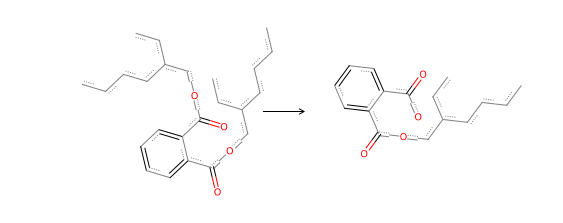

In [57]:
import pubchempy
from rdkit.Chem import rdChemReactions
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D, rdDepictor
import rdkit

rxn = rdChemReactions.ReactionFromSmarts(rxn_smiles)
drawer = rdMolDraw2D.MolDraw2DSVG(-1,-1)
dopts = drawer.drawOptions()
dopts.bondLineWidth = 1.0 # default is 2.0
drawer.DrawReaction(rxn)
drawer.FinishDrawing()
import IPython.display
i = IPython.display.SVG(drawer.GetDrawingText())
display(i)


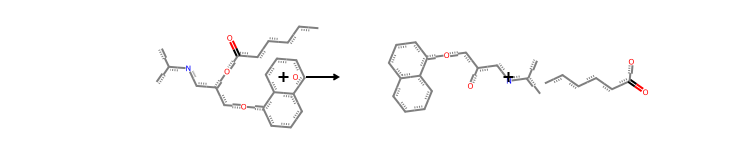

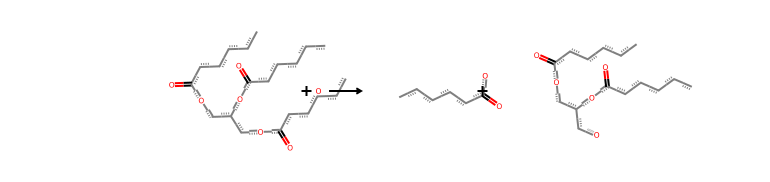

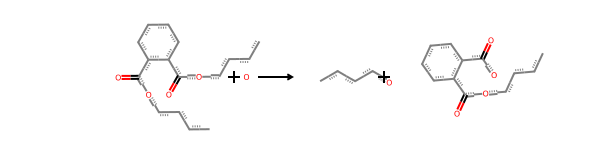

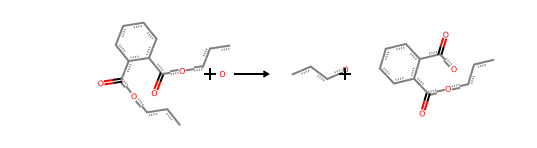

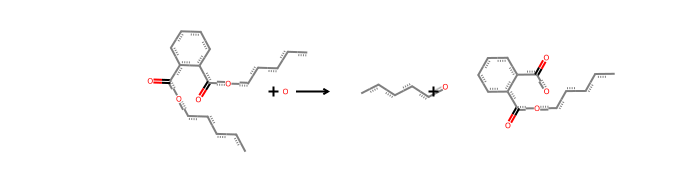

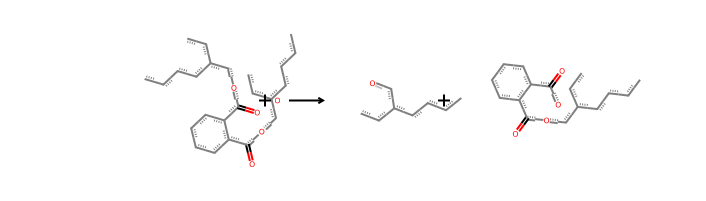

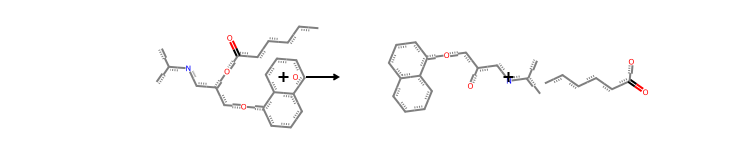

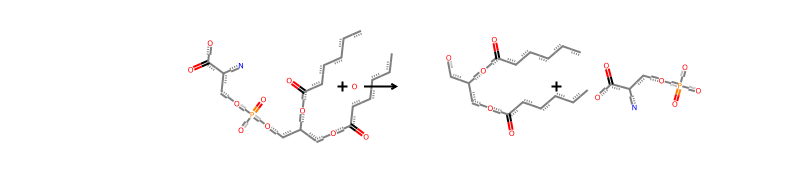

In [58]:
import IPython.display

names = []
smiles_to_name = {}
ms = []

for c in set(top_reaction_distance_df['unmapped'].values):
    rxn = rdChemReactions.ReactionFromSmarts(c)
    #rxn = remove_atom_mapping(rxn)
    drawer = rdMolDraw2D.MolDraw2DSVG(-1,-1)
    dopts = drawer.drawOptions()
    dopts.addAtomIndices = False 
    dopts.bondLineWidth = 2.0 # default is 2.0
    drawer.DrawReaction(rxn)
    drawer.FinishDrawing()
    i = IPython.display.SVG(drawer.GetDrawingText())
    display(i)

# Filter for bacteria and archaea 

Here are some filters we apply for expressing in ecoli may or may not be useful for you.

In [61]:
top_reaction_distance_df.columns


Index(['Unnamed: 0', 'rxn_idx', 'mapped', 'unmapped', 'orig_rxn_text', 'rule',
       'rule_id', 'source', 'steps', 'quality', 'natural', 'organism',
       'protein_refs', 'protein_db', 'ec_num', 'id', 'substrates', 'products',
       'substrates_MolWt', 'substrates_TPSA', 'substrates_MolLogP',
       'substrates_MaxPartialCharge', 'substrates_MinPartialCharge',
       'products_MolWt', 'products_TPSA', 'products_MolLogP',
       'products_MaxPartialCharge', 'products_MinPartialCharge'],
      dtype='object')

In [62]:
from sciutil import SciUtil

length_filter = 300

u = SciUtil()

data_folder = '../../manuscript/'
protein_info = pd.read_csv(f'{data_folder}uniprotkb_reviewed_true_2025_17_02.tsv', sep='\t')
# Filter for "short" bacterial sequences
ec_numbers = set(top_reaction_distance_df['ec_num'].values)
proteins = protein_encoding_df[protein_encoding_df['EC number'].isin(ec_numbers)]

proteins = proteins[proteins['Length'] < length_filter]

# Finally select those that come from bacteria for obvious reasons...
protein_all_info = protein_info[protein_info['Entry'].isin(proteins['Entry'].values)]
# 2157 or 2 (archaea or bacteria)
protein_all_info['superkingdom'] = [c.split(',')[1].split(' ')[1].strip() for c in protein_all_info['Taxonomic lineage (Ids)'].values]

u.dp(['Superkingdom'])
print(protein_all_info['superkingdom'].value_counts())
protein_all_info = protein_all_info[protein_all_info['superkingdom'].isin(['2', '2157'])]

# Add in if you want to remove cofactors
u.dp(['Cofactors'])
print(protein_all_info['Cofactor'].value_counts())
protein_all_info = protein_all_info[protein_all_info['Cofactor'].isna()]

u.dp(['Subunits'])
print(protein_all_info['Subunit structure'].value_counts())
protein_all_info['Subunit'] = ['Monomer or Homodimer' if (isinstance(s, (int, float, complex)) or 'Monomer' in s or 'Homodimer' in s) else 'Complex' for s in protein_all_info['Subunit structure'].values]
protein_all_info = protein_all_info[protein_all_info['Subunit'] == 'Monomer or Homodimer']

protein_all_info.to_csv(os.path.join(output_dir, f'{label}_enzymes_based_on_substrates.csv'), index=False)
protein_all_info

/tmp/ipykernel_3508991/2392977541.py:8: DtypeWarning: Columns (19,21,22,29) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_info = pd.read_csv(f'{data_folder}uniprotkb_reviewed_true_2025_17_02.tsv', sep='\t')


--------------------------------------------------------------------------------
                                 Superkingdom	                                  
--------------------------------------------------------------------------------
superkingdom
2759    53
2       16
Name: count, dtype: int64
--------------------------------------------------------------------------------
                                   Cofactors	                                   
--------------------------------------------------------------------------------
Cofactor
COFACTOR: Name=Zn(2+); Xref=ChEBI:CHEBI:29105; Note=Binds 3 Zn(2+) ions per subunit.;                                                                                                                                                                                                                                                                                                                                                  2
COFACTOR: Name=Zn(2

/tmp/ipykernel_3508991/2392977541.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_all_info['superkingdom'] = [c.split(',')[1].split(' ')[1].strip() for c in protein_all_info['Taxonomic lineage (Ids)'].values]


,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Organism (ID),Taxonomic lineage (Ids),Mass,...,Transmembrane,Glycosylation,Post-translational modification,Disulfide bond,PubMed ID,DOI ID,PDB,BRENDA,superkingdom,Subunit
1498,A6WFI5,reviewed,CUTI_KINRD,Cutinase (EC 3.1.1.74) (KrCUT),cut Krad_4111 YP_001363838.1,Kineococcus radiotolerans (strain ATCC BAA-149...,294,266940,"131567 (no rank), 2 (superkingdom), 1783272 (k...",29136,...,NaN,NaN,NaN,"DISULFID 36..107; /evidence=""ECO:0000250|UniPr...",19057647; 34705546,10.1371/journal.pone.0003878; 10.1128/aem.0152...,NaN,NaN,2,Monomer or Homodimer
4454,I6XU97,reviewed,EST45_MYCTU,Esterase Rv0045c (EC 3.1.1.1),Rv0045c,Mycobacterium tuberculosis (strain ATCC 25618 ...,298,83332,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32131,...,NaN,NaN,NaN,NaN,9634230; 21139199; 20957207; 21969609; 2535408...,10.1038/31159; 10.1107/s1744309110026606; 10.1...,3P2M;6WYM;6WYN;,NaN,2,Monomer or Homodimer
4573,L0TC47,reviewed,LIPV_MYCTU,Lipase LipV (EC 3.1.1.1),lipV Rv3203,Mycobacterium tuberculosis (strain ATCC 25618 ...,261,83332,"131567 (no rank), 2 (superkingdom), 1783272 (k...",27868,...,NaN,NaN,NaN,NaN,9634230; 34915127; 21969609; 24234750,10.1038/31159; 10.1016/j.ygeno.2021.12.001; 10...,NaN,NaN,2,Monomer or Homodimer
20592,P37957,reviewed,ESTA_BACSU,Lipase EstA (Lipase A) (EC 3.1.1.3) (Triacylgl...,estA lip lipA BSU02700,Bacillus subtilis (strain 168),212,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",22791,...,NaN,NaN,NaN,NaN,1320940; 9274031; 9384377; 8396026; 11029590; ...,10.1016/0167-4781(92)90023-s; 10.1099/00221287...,1I6W;1ISP;1R4Z;1R50;1T2N;1T4M;2QXT;2QXU;3D2A;3...,NaN,2,Monomer or Homodimer
41627,Q79F14,reviewed,ESTB_BACSU,Extracellular esterase EstB (EC 3.1.1.3) (Extr...,estB lipB yfiP BSU08350,Bacillus subtilis (strain 168),210,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",22363,...,NaN,NaN,NaN,NaN,8973323; 9384377; 11029590; 11583117,10.1016/s0378-1119(96)00495-7; 10.1038/36786; ...,NaN,3.1.1.23;,2,Monomer or Homodimer
103651,Q93J06,reviewed,LIP2_STRCO,Lipase 2 (EC 3.1.1.3),SCO7513 SCBAC25F8.05c,Streptomyces coelicolor (strain ATCC BAA-471 /...,295,100226,"131567 (no rank), 2 (superkingdom), 1783272 (k...",30494,...,NaN,NaN,NaN,"DISULFID 65..89; /evidence=""ECO:0000250""; DISU...",12000953,10.1038/417141a; 10.1016/j.enzmictec.2008.01.009,NaN,3.1.1.3;,2,Monomer or Homodimer
189271,O32232,reviewed,EST_BACSU,Carboxylesterase (EC 3.1.1.1),est yvaK BSU33620,Bacillus subtilis (strain 168),246,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",28193,...,NaN,NaN,NaN,NaN,9384377; 17369301,10.1038/36786; 10.1128/jb.00062-07,NaN,NaN,2,Monomer or Homodimer
222722,Q06174,reviewed,EST_GEOSE,Carboxylesterase (EC 3.1.1.1),est est30,Geobacillus stearothermophilus (Bacillus stear...,246,1422,"131567 (no rank), 2 (superkingdom), 1783272 (k...",28256,...,NaN,NaN,NaN,NaN,1369099; 15033540; 15327954,10.1271/bbb.56.2074; 10.1016/j.gene.2003.12.02...,1R1D;1TQH;8ILT;,3.1.1.1;,2,Monomer or Homodimer
258585,Q53547,reviewed,EST2_PSEFL,Carboxylesterase 2 (EC 3.1.1.1) (Esterase II),estB,Pseudomonas fluorescens,218,294,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",23880,...,NaN,NaN,NaN,NaN,1368750; 9438866,10.1271/bbb1961.55.2839; 10.1016/s0969-2126(97...,1AUO;1AUR;,NaN,2,Monomer or Homodimer
312833,Q9HZY8,reviewed,EST_PSEAE,Esterase TesA (EC 3.1.1.1),tesA PA2856,Pseudomonas aeruginosa (strain ATCC 15692 / DS...,201,208964,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",21038,...,NaN,NaN,NaN,NaN,10984043; 20931591,10.1038/35023079; 10.1002/cbic.201000398,4JGG;,NaN,2,Monomer or Homodimer


# We have a very different list to the one above now owing to filtering the reactions

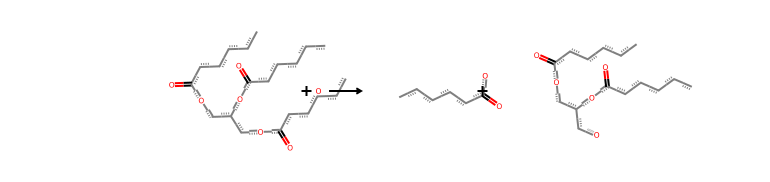

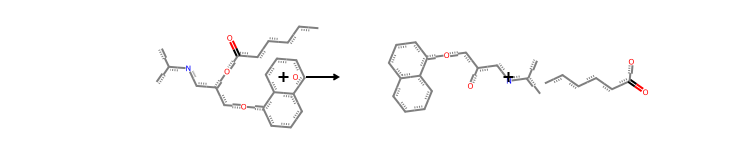

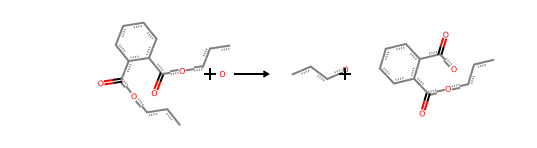

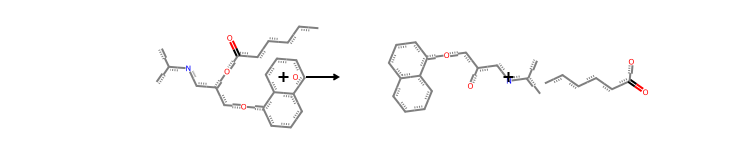

In [65]:
import IPython.display

names = []
smiles_to_name = {}
ms = []

# Now we need to filter for the reactions that have proteins remaining after doing the protein filter.
top_reaction_distance_df = top_reaction_distance_df[top_reaction_distance_df['ec_num'].isin(list(protein_all_info['EC number'].values))]
for c in set(top_reaction_distance_df['unmapped'].values):
    rxn = rdChemReactions.ReactionFromSmarts(c)
    #rxn = remove_atom_mapping(rxn)
    drawer = rdMolDraw2D.MolDraw2DSVG(-1,-1)
    dopts = drawer.drawOptions()
    dopts.addAtomIndices = False 
    dopts.bondLineWidth = 2.0 # default is 2.0
    drawer.DrawReaction(rxn)
    drawer.FinishDrawing()
    i = IPython.display.SVG(drawer.GetDrawingText())
    display(i)

# Now if you have many reactions you'll need to further filter these.

In [66]:
from enzymetk.similarity_mmseqs_step import MMseqs
from enzymetk.save_step import Save
import pandas as pd

id_col = 'Entry'
seq_col = 'Sequence'
protein_all_info << (MMseqs(id_col, seq_col, method='cluster', args=['--min-seq-id', '0.8', '-c', '0.8', '--cov-mode', '0']) >> Save(f'{output_dir}{label}_mmseqs_files_reactions.pkl'))


--------------------------------------------------------------------------------
Running command	mmseqs easy-cluster /tmp/tmp5utroy47/seqs.fasta /tmp/tmp5utroy47/clusterRes /tmp/tmp5utroy47/tmp --min-seq-id 0.8 -c 0.8 --cov-mode 0	
--------------------------------------------------------------------------------


2026-05-25 15:42:08,907 - enzymetk.step - INFO - Create directory /tmp/tmp5utroy47/tmp
easy-cluster /tmp/tmp5utroy47/seqs.fasta /tmp/tmp5utroy47/clusterRes /tmp/tmp5utroy47/tmp --min-seq-id 0.8 -c 0.8 --cov-mode 0 

MMseqs Version:                     	18.8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.8
Coverage mode                       	0
Compositional bias                  	1
Compositional bias scale            	1
D

--------------------------------------------------------------------------------
                                    Output:	                                    
--------------------------------------------------------------------------------
Create directory /tmp/tmp5utroy47/tmp
easy-cluster /tmp/tmp5utroy47/seqs.fasta /tmp/tmp5utroy47/clusterRes /tmp/tmp5utroy47/tmp --min-seq-id 0.8 -c 0.8 --cov-mode 0 

MMseqs Version:                     	18.8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Spli

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Organism (ID),Taxonomic lineage (Ids),Mass,...,Glycosylation,Post-translational modification,Disulfide bond,PubMed ID,DOI ID,PDB,BRENDA,superkingdom,Subunit,mmseqs_representative_cluster_seq
0,A6WFI5,reviewed,CUTI_KINRD,Cutinase (EC 3.1.1.74) (KrCUT),cut Krad_4111 YP_001363838.1,Kineococcus radiotolerans (strain ATCC BAA-149...,294,266940,"131567 (no rank), 2 (superkingdom), 1783272 (k...",29136,...,NaN,NaN,"DISULFID 36..107; /evidence=""ECO:0000250|UniPr...",19057647; 34705546,10.1371/journal.pone.0003878; 10.1128/aem.0152...,NaN,NaN,2,Monomer or Homodimer,A6WFI5
1,I6XU97,reviewed,EST45_MYCTU,Esterase Rv0045c (EC 3.1.1.1),Rv0045c,Mycobacterium tuberculosis (strain ATCC 25618 ...,298,83332,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32131,...,NaN,NaN,NaN,9634230; 21139199; 20957207; 21969609; 2535408...,10.1038/31159; 10.1107/s1744309110026606; 10.1...,3P2M;6WYM;6WYN;,NaN,2,Monomer or Homodimer,I6XU97
2,L0TC47,reviewed,LIPV_MYCTU,Lipase LipV (EC 3.1.1.1),lipV Rv3203,Mycobacterium tuberculosis (strain ATCC 25618 ...,261,83332,"131567 (no rank), 2 (superkingdom), 1783272 (k...",27868,...,NaN,NaN,NaN,9634230; 34915127; 21969609; 24234750,10.1038/31159; 10.1016/j.ygeno.2021.12.001; 10...,NaN,NaN,2,Monomer or Homodimer,L0TC47
3,P37957,reviewed,ESTA_BACSU,Lipase EstA (Lipase A) (EC 3.1.1.3) (Triacylgl...,estA lip lipA BSU02700,Bacillus subtilis (strain 168),212,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",22791,...,NaN,NaN,NaN,1320940; 9274031; 9384377; 8396026; 11029590; ...,10.1016/0167-4781(92)90023-s; 10.1099/00221287...,1I6W;1ISP;1R4Z;1R50;1T2N;1T4M;2QXT;2QXU;3D2A;3...,NaN,2,Monomer or Homodimer,P37957
4,Q79F14,reviewed,ESTB_BACSU,Extracellular esterase EstB (EC 3.1.1.3) (Extr...,estB lipB yfiP BSU08350,Bacillus subtilis (strain 168),210,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",22363,...,NaN,NaN,NaN,8973323; 9384377; 11029590; 11583117,10.1016/s0378-1119(96)00495-7; 10.1038/36786; ...,NaN,3.1.1.23;,2,Monomer or Homodimer,Q79F14
5,Q93J06,reviewed,LIP2_STRCO,Lipase 2 (EC 3.1.1.3),SCO7513 SCBAC25F8.05c,Streptomyces coelicolor (strain ATCC BAA-471 /...,295,100226,"131567 (no rank), 2 (superkingdom), 1783272 (k...",30494,...,NaN,NaN,"DISULFID 65..89; /evidence=""ECO:0000250""; DISU...",12000953,10.1038/417141a; 10.1016/j.enzmictec.2008.01.009,NaN,3.1.1.3;,2,Monomer or Homodimer,Q93J06
6,O32232,reviewed,EST_BACSU,Carboxylesterase (EC 3.1.1.1),est yvaK BSU33620,Bacillus subtilis (strain 168),246,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",28193,...,NaN,NaN,NaN,9384377; 17369301,10.1038/36786; 10.1128/jb.00062-07,NaN,NaN,2,Monomer or Homodimer,O32232
7,Q06174,reviewed,EST_GEOSE,Carboxylesterase (EC 3.1.1.1),est est30,Geobacillus stearothermophilus (Bacillus stear...,246,1422,"131567 (no rank), 2 (superkingdom), 1783272 (k...",28256,...,NaN,NaN,NaN,1369099; 15033540; 15327954,10.1271/bbb.56.2074; 10.1016/j.gene.2003.12.02...,1R1D;1TQH;8ILT;,3.1.1.1;,2,Monomer or Homodimer,Q06174
8,Q53547,reviewed,EST2_PSEFL,Carboxylesterase 2 (EC 3.1.1.1) (Esterase II),estB,Pseudomonas fluorescens,218,294,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",23880,...,NaN,NaN,NaN,1368750; 9438866,10.1271/bbb1961.55.2839; 10.1016/s0969-2126(97...,1AUO;1AUR;,NaN,2,Monomer or Homodimer,Q51758
9,Q9HZY8,reviewed,EST_PSEAE,Esterase TesA (EC 3.1.1.1),tesA PA2856,Pseudomonas aeruginosa (strain ATCC 15692 / DS...,201,208964,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",21038,...,NaN,NaN,NaN,10984043; 20931591,10.1038/35023079; 10.1002/cbic.201000398,4JGG;,NaN,2,Monomer or Homodimer,Q9HZY8


In [67]:
clustered_seqs = pd.read_pickle(f'{output_dir}{label}_mmseqs_files_reactions.pkl')
clustered_seqs['mmseqs_representative_cluster_seq'].value_counts()

mmseqs_representative_cluster_seq
Q51758    2
I6XU97    1
A6WFI5    1
L0TC47    1
P37957    1
Q93J06    1
Q79F14    1
O32232    1
Q06174    1
Q9HZY8    1
O31452    1
Name: count, dtype: int64

# Just order the cluster centers to avoid duplicates

here you may want to investigate each since it's not many otherwise you can just order the cluster centres.

In [68]:
cluster_centres = set(clustered_seqs['mmseqs_representative_cluster_seq'].value_counts().index)
protein_all_info = protein_all_info[protein_all_info['Entry'].isin(cluster_centres)]
protein_all_info

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Organism (ID),Taxonomic lineage (Ids),Mass,...,Transmembrane,Glycosylation,Post-translational modification,Disulfide bond,PubMed ID,DOI ID,PDB,BRENDA,superkingdom,Subunit
1498,A6WFI5,reviewed,CUTI_KINRD,Cutinase (EC 3.1.1.74) (KrCUT),cut Krad_4111 YP_001363838.1,Kineococcus radiotolerans (strain ATCC BAA-149...,294,266940,"131567 (no rank), 2 (superkingdom), 1783272 (k...",29136,...,NaN,NaN,NaN,"DISULFID 36..107; /evidence=""ECO:0000250|UniPr...",19057647; 34705546,10.1371/journal.pone.0003878; 10.1128/aem.0152...,NaN,NaN,2,Monomer or Homodimer
4454,I6XU97,reviewed,EST45_MYCTU,Esterase Rv0045c (EC 3.1.1.1),Rv0045c,Mycobacterium tuberculosis (strain ATCC 25618 ...,298,83332,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32131,...,NaN,NaN,NaN,NaN,9634230; 21139199; 20957207; 21969609; 2535408...,10.1038/31159; 10.1107/s1744309110026606; 10.1...,3P2M;6WYM;6WYN;,NaN,2,Monomer or Homodimer
4573,L0TC47,reviewed,LIPV_MYCTU,Lipase LipV (EC 3.1.1.1),lipV Rv3203,Mycobacterium tuberculosis (strain ATCC 25618 ...,261,83332,"131567 (no rank), 2 (superkingdom), 1783272 (k...",27868,...,NaN,NaN,NaN,NaN,9634230; 34915127; 21969609; 24234750,10.1038/31159; 10.1016/j.ygeno.2021.12.001; 10...,NaN,NaN,2,Monomer or Homodimer
20592,P37957,reviewed,ESTA_BACSU,Lipase EstA (Lipase A) (EC 3.1.1.3) (Triacylgl...,estA lip lipA BSU02700,Bacillus subtilis (strain 168),212,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",22791,...,NaN,NaN,NaN,NaN,1320940; 9274031; 9384377; 8396026; 11029590; ...,10.1016/0167-4781(92)90023-s; 10.1099/00221287...,1I6W;1ISP;1R4Z;1R50;1T2N;1T4M;2QXT;2QXU;3D2A;3...,NaN,2,Monomer or Homodimer
41627,Q79F14,reviewed,ESTB_BACSU,Extracellular esterase EstB (EC 3.1.1.3) (Extr...,estB lipB yfiP BSU08350,Bacillus subtilis (strain 168),210,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",22363,...,NaN,NaN,NaN,NaN,8973323; 9384377; 11029590; 11583117,10.1016/s0378-1119(96)00495-7; 10.1038/36786; ...,NaN,3.1.1.23;,2,Monomer or Homodimer
103651,Q93J06,reviewed,LIP2_STRCO,Lipase 2 (EC 3.1.1.3),SCO7513 SCBAC25F8.05c,Streptomyces coelicolor (strain ATCC BAA-471 /...,295,100226,"131567 (no rank), 2 (superkingdom), 1783272 (k...",30494,...,NaN,NaN,NaN,"DISULFID 65..89; /evidence=""ECO:0000250""; DISU...",12000953,10.1038/417141a; 10.1016/j.enzmictec.2008.01.009,NaN,3.1.1.3;,2,Monomer or Homodimer
189271,O32232,reviewed,EST_BACSU,Carboxylesterase (EC 3.1.1.1),est yvaK BSU33620,Bacillus subtilis (strain 168),246,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",28193,...,NaN,NaN,NaN,NaN,9384377; 17369301,10.1038/36786; 10.1128/jb.00062-07,NaN,NaN,2,Monomer or Homodimer
222722,Q06174,reviewed,EST_GEOSE,Carboxylesterase (EC 3.1.1.1),est est30,Geobacillus stearothermophilus (Bacillus stear...,246,1422,"131567 (no rank), 2 (superkingdom), 1783272 (k...",28256,...,NaN,NaN,NaN,NaN,1369099; 15033540; 15327954,10.1271/bbb.56.2074; 10.1016/j.gene.2003.12.02...,1R1D;1TQH;8ILT;,3.1.1.1;,2,Monomer or Homodimer
312833,Q9HZY8,reviewed,EST_PSEAE,Esterase TesA (EC 3.1.1.1),tesA PA2856,Pseudomonas aeruginosa (strain ATCC 15692 / DS...,201,208964,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",21038,...,NaN,NaN,NaN,NaN,10984043; 20931591,10.1038/35023079; 10.1002/cbic.201000398,4JGG;,NaN,2,Monomer or Homodimer
411981,O31452,reviewed,YBFK_BACSU,Carboxylesterase YbfK (EC 3.1.1.1),ybfK BSU02260,Bacillus subtilis (strain 168),296,224308,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33071,...,NaN,NaN,NaN,NaN,9384377; 11389736,10.1038/36786; 10.1046/j.1432-1327.2001.02238.x,4CCY;,NaN,2,Monomer or Homodimer


# Optionally use oligopoolio 

First you need to codon optimize using IDT, so I print them out here then copy and paste into IDTs online codon optimzier:

In [69]:
for entry, seq in protein_all_info[['Entry', 'Sequence']].values:
    print(f'>{entry}\n{seq}')

>A6WFI5
MLRARPSHRLASAAAVVAATGAALLAGSSPAAAATCSDVDVVFARGTGETPGLGVVGGPFVRSLTGELSDRTVTSHAVDYAASSSQASAGPGATAMSAHVREVAAACPSTRFVLGGYSQGATVTDIALGIRTGTTTGTPVPAELAGRVAAVVVFGNPLGLSGRTIATASSTYGPKSKDYCNSSDSVCGSAPKTGTGGHLSYASNGSTTDGARFAAGLVRAAGTPTTPTPTPTPTPVPTTCVRDSTRDHVAADRAVSLYGRAYARGSRDSLGATSSYNVVSLQQVEGGWRLVTAC
>I6XU97
MLSDDELTGLDEFALLAENAEQAGVNGPLPEVERVQAGAISALRWGGSAPRVIFLHGGGQNAHTWDTVIVGLGEPALAVDLPGHGHSAWREDGNYSPQLNSETLAPVLRELAPGAEFVVGMSLGGLTAIRLAAMAPDLVGELVLVDVTPSALQRHAELTAEQRGTVALMHGEREFPSFQAMLDLTIAAAPHRDVKSLRRGVFHNSRRLDNGNWVWRYDAIRTFGDFAGLWDDVDALSAPITLVRGGSSGFVTDQDTAELHRRATHFRGVHIVEKSGHSVQSDQPRALIEIVRGVLDTR
>L0TC47
MIIDLHVQRYGPSGPARVLTIHGVTEHGRIWHRLAHHLPEIPIAAPDLLGHGRSPWAAPWTIDANVSALAALLDNQGDGPVVVVGHSFGGAVAMHLAAARPDQVAALVLLDPAVALDGSRVREVVDAMLASPDYLDPAEARAEKATGAWADVDPPVLDAELDEHLVALPNGRYGWRISLPAMVCYWSELARDIVLPPVGTATTLVRAVRASPAYVSDQLLAALDKRLGADFELLDFDCGHMVPQAKPTEVAAVIRSRLGPR
>P37957
MKFVKRRIIALVTILMLSVTSLFALQPSAKAAEHNPVVMVHGIGGASFNFAGIKSYLVSQGWSRDKLYAVDFWDKTGTNYNNGPVLSRFVQKVLDETGAKKVDIVAHSMGGA

# Paste back in the codon optimized data

In [27]:
optimized = {'O35016': 'ATGATCTCTGTTTTATTCGTATGCCTGGGAAACATCTGTCGTAGTCCTATGGCGGAAGCGATTTTCCGTGATCTTGCAGCCAAGAAAGGCTTGGAGGGTAAAATCAAGGCGGACTCCGCCGGGATTGGGGGATGGCATATTGGAAATCCTCCACATGAGGGGACACAAGAAATCTTACGTCGCGAAGGTATTAGCTTTGATGGTATGTTGGCCCGCCAGGTCAGCGAACAGGATCTTGACGATTTCGACTACATTATTGCGATGGATGCGGAGAATATTGGCTCGCTTCGTTCTATGGCGGGATTCAAAAACACCAGTCATATCAAGCGTTTACTGGACTATGTCGAAGATAGTGACCTTGCGGACGTGCCGGACCCCTATTATACTGGTAATTTTGAAGAGGTTTGCCAGTTAATCAAGACAGGCTGTGAGCAATTGCTTGCAAGTATCCAGAAAGAGAAGCAATTG', 
             'O52787': 'ATGCAGTTCAAGAACATCCTTGTTGTGTGCATCGGTAACATCTGCCGTAGCCCTATGGCCGAGTACCTTCTGAAACAAAATTATCCTCAACTTACAATTCATTCGGCTGGGATCAGTGGCATGATCGGATACTCTGCTGACGAGAAAGCGCAATTGTGCATGGAACGCATTGGGATTGATATGTCGCCCCATATTGCTAAAAAATTAAACGCTGAACTTCTGAAACAGGCTGATTTAATTCTGGTGATGTCGCAGAACCAACAAAAGCACATCGAGCAAACGTGGCCTTTCGCCAAAGGGAAGACTTTTCGCTTAGGACACTGGCAAGGCAAAAACATCCCCGATCCATATCAACACGATCAGGCGTTTTTTGACGAGACGAGTCTTCTGATTCAAACTTGCGTCGCCGACTGGACAAAGCATATC', 
             'P0C5D3': 'ATGAAAATCCTTTTTGTGTGTACAGGAAATACATGTCGTTCCCCATTGGCCGAATCTATCGCTAAAGAAGTAATGCCAAATCATCAATTCGAGTCGCGTGGGATCTTCGCTGTGAATAACCAAGGAGTTAGCAACTATGTTGAGGATTTAGTGGAGGAGCACCATCTGGCGGAAACAACGTTGTCACAGCAGTTCACTGAAGCTGATCTTAAGGCGGACATCATTCTGACCATGTCGTACTCGCACAAAGAATTGATCGAGGCGCACTTCGGGCTTCAGAACCACGTGTTTACGCTGCACGAATACGTTAAAGAGGCTGGCGAAGTGATCGACCCCTACGGCGGTACTAAAGAAATGTACGTGCACACCTACGAAGAACTTGTCTCCCTGATCCTTAAATTAAAAGACATTATTTGT', 
             'P39852': 'ATGGTGGATATTCATAATCACATCTTGGTAGACGTTGACGATGGTCCCAAATCAATCAATGAAGCCATTGAATTGTTAAAACAGGCCCAGAGCGAAAATGTGACCGATATCGTAGCGACTCCACACCATCTGCACAAACGTTATAGTAATGACATCGAAAAGGTGAAGATCAAGCTTAACGAGTTGAAAAATAATTCAGAGATCAAAAAATTAGGCTTAAACCTGTACGTAGGCCAAGAAATCCGCATCACTGATCAGATTATCGAAGGCATTAAGAACAAAGAGATCGAAGGGATTAACGAGTCTCGCTACTTACTTATTGAGTTCCCAAGCAATGAGATTCCTTACTACACTAACCAGCTGTTCTACGAATTGCAAACAATGGGATATATTCCGATCATCGCTCACCCGGAACGCAACAAAGCTATCGTCCAAAATTTGGACTTGCTTTTTGAGTTAATCAACGGAGGCGCTCTTTCCCAAATTACCGCTTCATCCCTTTTAGGTGACTTCGGGAATAACATTCGCAAGCTGAGCCTTAAGATGATCGACAGCAACTTGGCGCATTTTATCGCGAGCGATGCACATTCTATCACCAACCGTCCTTTCATGCTGAAACAGTTATTCAATGACCGCAAGCTTAAAGCTTACTATGAGGAGCTGGAGTCCTATCTTAAGAATGGTAAACTGGTCCTTACCAATGAACGTATCTCAAAACAAATTCCTACTCAAGATTACAAACAGAAAAAGTGGTTTGGCCTGCTT', 
             'Q05918': 'ATGAAAACTCATCATGCAAACCTGGCGCTGGCTCTGATGTTGGGACTGTCTAGCAGTGCCACAGCGGTCGCGGCCGACGCGCCACAAGCGGTAGCAACAAAGGCCGCGGCCCCAAACGTAAAACCTGTCGCTGCGGATGCACATGGTGTCATCCCCGACGGAGCTCCAGGTATGTGTGCCCGCAGTCCTGCTTGCCGCGCCACCGCCATCCCCGCGGACGCATTTGTCCGCACAGCTGATCTGGGCCGCCTTACGGATGCTGATCGTGACGCTCTTGCTGCTTTAGGAGTAAAGTTGGACATCGACTTGCGTACAGCAGATGAGGAAGCCCAGTCACCAGACTTATTAGCCCGTGACGACCGCTTTGACTACCAACGTATTTCTTTAATGGGAACTGAAAAAATGGACTTGCAGAAGATGATGACATCCTTTCCAGATTCGCTTGGAGAAGCGTATGTGCAATGGTTGGGGCACAGCCAACCTCAGTTCAAACAAGTTTTTCAGCGTATCGCAGCGCAACAAGACGGTGCCGTTCTGTTTCACTGCACCGCGGGAAAAGACCGTACTGGTATCATCGCGGGGTTATTGTTAGATTTAGCGGGTGTCCCTAAGGCCGAAATCGTGCACAATTATGCAATCTCTGCGCACTATTTAGAGGGACAACCAAAGGATTCGGACGAGCGTGCAGATCATGGGGCTGGCCAGGCGGAGCCTGGGGACCGCCCACAAGACGGCGGGCATGGTCGTTATCGCGCTGGACAACACGGAGCTGTTTTGGCAGCCTTACATTCACAATATGGGGGAGCAGAAGGGTACTTGAAATCAATTGGGGTTTCCGAACAAGAAATCCAGCAATTAAAAGTACGCTTAGGCCAAGCTGGT', 
             'Q92G53': 'ATGAAGCGTAAGAACAACAAATTCATCGAGATTTCTATTGCGTTCATTCTGGGGATCGCATTAGGGTTGTACGGTCAAAATCCTGACTACTTCACCAACCTGATCAGCCAAAAAAGCTTGGCGTTAAGCGCTTTGCAAATTAAGCATTACAACATCTCGGAATTATCCCGCTCTAAAGTCTCGACCTGCTTTACCCCCCCTGCCGGATGTACGAAGTTCATCGCCAACCAAATCGATAAGGCCGAAGAGAGCATTTACATGCAGGCTTACGGGATGAGCGATGCCCTGATTACAACAGCATTGATCAATGCACAGGCACGCGGTGTCAAAGTACGCATCCTTCTGGATCGCAGCAACCTGAAACAGAAATTCTCCAAGTTGCATGAGTTACAACGCGCTAAAATTGATGTGGATATCGATAAGGTCCCTGGAATCGCACATAACAAAGTGATCATCATCGACAAGAAAAAGGTAATCACTGGCTCTTTCAACTTTACAGCCGCGGCTGACAAGCGTAACGCTGAGAACGTAATCATTATTGAAGACCAGGAGTTGGCTGAATCGTACTTGCAAAACTGGCTTAACCGTAAAGCCTCGAAT', 
             'Q9FAW5': 'ATGAAATTGGTCGTAATTAATGGCACCCCGCGTAAATTCGGCCGCACACGTGTAGTAGCAAAATACATTGCAGATCAATTTGAAGGCGAGCTGTATGATTTAGCTATTGAGGAGCTTCCCTTATATAATGGTGAGGAAAGTCAGCGCGATTTGGAAGCCGTCAAGAAACTGAAGACGTTAGTGAAGGCGGCCGATGGTGTAGTTTTATGCACCCCCGAGTATCATAATGCAATGTCCGGAGCGCTTAAAAATTCCTTGGACTATCTTAGTTCCTCCGAGTTCATCCACAAACCTGTGGCCTTGCTGGCGGTAGCTGGGGGAGGTAAAGGAGGAATTAACGCATTAAACAGTATGCACGCCTCTTTAGCCGGAGTTTATGCCAACGCCATTCCCAAACAAGTCGTGCTTGACGGCCTGCATGTGCAGGATGGTGAGTTAGGGGAGGATGCCAAACCCCTTATCCACGATGTCGTTAAGGAGTTAAAAGCGTATATGTCAGTCTATAAGGAAGTCAAAAAACAGTTAGGTGTTGAA', 
             'P26975': 'ATGAAGAAACTTCTTGCAGTCTTTTGCGCAGGTGCATTTGTTTCTACTTCCGTGTTTGCGGCCATCCCGCCCGGAAACGACGTTACAACTAAACCAGACCTGTACTATCTTAAGAACAGCCAAGCTATTGATTCGCTTGCGCTGCTGCCGCCTCCACCTGAGGTGGGTTCCATTTTATTCCTTAACGATCAAGCGATGTACGAAAAGGGTCGTCTGCTTCGCAACACTGAGCGTGGAGAGCAGGCTGCGAAGGATGCTGATCTTGCTGCGGGTGGGGTTGCAAACGCATTCTCGGAAGCCTTTGGATATCCCATCACCGAGAAAGACGCCCCTGAAATCCACAAACTTCTTACGAATATGATCGAGGATGCAGGGGACTTGGCCACCCGCTCCGCAAAAGAAAAGTACATGCGCATTCGCCCGTTTGCGTTCTACGGTGTGGCTACGTGCAATACGAAGGATCAGGATAAATTGTCCAAGAACGGTTCTTATCCTTCTGGACATACAGCAATTGGATGGGCATCGGCTCTTGTATTGAGTGAGATCAACCCCGAGAATCAAGATAAGATCTTAAAGCGCGGATACGAGCTGGGGCAGTCGCGTGTGATCTGTGGGTATCATTGGCAATCTGATGTTGACGCCGCTCGCATTGTAGCATCCGGGGCGGTGGCCACGTTGCATAGTAATCCAGAGTTCCAAAAGCAATTGCAGAAAGCGAAGGATGAGTTCGCGAAGCTGAAGAAA', 
             'P40289': 'ATGATCAAATGGTTACAGCGCGCAGGGTGTTTGAGTGCACATGCGGTGGTACCGCAGGCCCCGGCCGCTGCGTCCGTTCAAGGTCGCCACGACCTTGCGTTCGATACAATTTCAAATGCTCGTGATCTTGGTGGACTGGCTGGTGCTGGTGGACGCCGTGTACGTCAAGGGCGTTTATACCGCTCGGGTAACCCTGCATTAGCTAGTGCGGCAGACTTAGAGCGTTTGCAGACGTTGGGGTTGGATATGGTAGTGGATTTTCGCTCCCCAGGCGAAAAAAGCCCTGAGGAGGCTGCGTTCGGGCAACGTTTCCACTGGGTAGCGGCGCCGGTTTTGGAAGGAAGCATGGCAATGGATGTGTTAATGCCCCGCCTGCGCGCCTCAACGCCCGCTCAAATGGACGCTTTCATGCTTGAGGTGTATGGCGATTTCCCGGTCCGCTACCGTGAAGCTTTTGCAGGCTTCATGCGCACAGCACAAGGAGGAAAGACGTTACTTTTTCACTGTACGGCAGGGAAGGATCGTACCGGGTTTGCTGCCCTTCTTTTACTGGCTGCCCTTGGCGTAGCGCAAGACGATATTTTAGCTAATTACTTAGAATCGAACCAACGTAATGCGCAATTCAATCAAACCGCGCTTGCGCGTATGGCGGGTTTAGGGGTAGCCCCCGCAGTAATGACTCCTTTGCTTGAGGTACGTGCATCGTACCTTGACGCCTCTATGCGCGCCATTGATGCCGGGTGGGGATCTGTCGATAATTATTTACGTGACGCCTTGGAGGTCGATGTAGCACAACTGCGCGGTCACTATCTTGCGGGG', 
             'P49409': 'ATGGCTCCGCGCAGTCTGTTTTTACAGCGTTTCCAACCCCGCGACCTTACAAAAGCTTGGAACCAGTTAAACCTGTTTGACGAAATTCAATTCGCGTTCCTTATTTACTCTCAAGTGTATTCTAAGACCTTAATGGATTTTCAAAAGCGTTGGGCGCAGGGAGTCCTGGACCTGGAGGAGAACGCTCCGCCTGTGGTCATCCTGAAGCAACTGGCTCATTTGCTGAAGAACAAAGTTTGCTACCATCCCCCCATGTTAGTAGACCATCCCGATTTAGCGCGTGAAAATGATCGTCATGTATTTGTTTACCTTTCACGTGAGAAGATGCAAAAAGTCCTTGAGGAAAAGTCCATTACATTCGGGCTGGAGGCGGTTTTGGCTACTACGATGCAGCCTTACCGCTCTGATCTTGTGTTACAAGAAATGGTTCGTGCACACAATATTGCATGGCCCCATCGTCGCGTGGAAGAACCTGACTTGGAGGGTTTTATTGCCATCTTCGCCTCGACACTGTTCATCCATTTATTGGAGTTAAAAGTTACCAATGTGTATGGACGCGAGGTTGCCTGTACTTTTTTTGTACGCCAGGGGACGGGCAACCGCTCGTACGACGTAATCGCGTGTGGCATTACTCAGTTCACCAAGAATGCCGGGGTTATGCCCCGCCCGGCAGTGCCCTCACCGGAGCCGGACTTAACCTTACGCCTTTCCGGTCCAAATCAGAAACGCGAGGAGGGAGACATGAAACCTGCTATCGTAAACCTGAAGAAAGAAACTAGCGCCACC', 
             'P58596': 'ATGATTAAGACTATCCTTGTTGTGTGCATTGGTAATATTTGCCGCAGTCCTATGGCGCAAGCACTGTTGCGTCAGTCTTTGCCGGGCGTTTCAGTTATCAGCGCGGGTATCGGTGCATTGTCTGGATATCCAGCCGACCCAAGCGCTGTGGAGGTGATGGCACATCATGGAATTGATATTAGCGAACACCGTGCTCAGCAATTAACGGGGAGCCTTGTATCACGCGCGGACCTTATTTTAGTGATGGATGGCGCTCAGAAACAGGAGATTCAATCACGCCATCCAGCAAAGACTGGAAGCGTGTTTCGTCTTGGCGAGATGGAGCAATTCGATATCGCTGACCCCTACCGTAAGCAATTGACAGCCTTTGAAGAAGCATTGGAAATGATTCAGCGTGGCGTTGATGCTTGGGTTCCGCGTATCCGTGCTCTTGGA', 
             'P75525': 'ATGGACTCAACGAATCAAAACTTGTTTGCGTCTCTTAGTAAGAAGGGCCCGGTACGCAAGGAAAACCAAGACTTTTCCGTCGTCACCTTCAACCGTTTTGGACAGCTTATGTCCCTTGTCTGCGATGGCCTGGGAGGCTATAAGGGAGGAAAGATGGCATCAGCGCTTGTGTCTGAAGTGTTTACTAAGTCGTTTACCGTTTTCGACTTCCACAGCCAAACGGAACGCGCGGTCAAACAGTGGTTCGAGATTACCCTGATCGAAGCACGCCGTACGTTGGAGCAATACTTCCAAACAATTAAGCGCAATCAAGTACAATTTGCCCGTATGGCAACTACACTGGTTCTGAGTATTATTTCCAAACAGAACATTTGGACGTTCTGGGTAGGGGACTCACGTGCATATTTAATCAACTCATATCAGTCTCTGCAAATCACCGAGGATCATAACCTGTATAATCAGCTGTTGCAGATGCACGCCACCCCGGATGTGATTGCGTCCTATAAGGATAAATTACTTGCTTTGACTGCGACGGTTAGTAAGGATCAAGAACGTCAGCTTAAATACTCTTTTCGCTGCGATGTTGTGAACGCTTGGGACTTTTTGTTATTATGCAGTGATGGGTTATACAATTTCCTGGATCCAAATTGCTTTTATGAGGTGATCACTAGCGCTCCCAACCTTAAAAAGGCCGTGACACAATTAGCGAAGTTATCGCTGGATAACGCGTCCAACGACAACATCACGTTGAATCTGATTAATTTAAAGCAATGGCAC',
             'P9WIA0': 'ATGTCAGATCCGCTGCACGTTACATTCGTCTGCACGGGTAACATTTGTCGTAGTCCCATGGCCGAAAAGATGTTCGCGCAGCAATTACGCCACCGTGGCTTGGGCGATGCAGTACGCGTCACGTCTGCTGGCACAGGAAATTGGCACGTCGGGTCTTGCGCGGATGAACGCGCAGCCGGCGTCCTTCGTGCTCATGGTTATCCAACAGACCATCGTGCCGCGCAGGTCGGTACAGAGCATTTGGCCGCAGACCTGCTTGTTGCTTTAGATCGTAATCACGCGCGCTTGCTGCGTCAGTTGGGTGTAGAAGCGGCACGCGTTCGCATGTTGCGTAGTTTTGACCCTCGCTCGGGGACACATGCTTTAGATGTAGAGGATCCCTATTACGGGGACCATAGTGATTTTGAGGAAGTTTTTGCTGTTATTGAAAGTGCCTTACCCGGATTGCATGATTGGGTGGACGAGCGTTTGGCCCGCAACGGTCCTAGC', 
             'Q48451': 'ATGTTTTCCACAATTCTTATCGTGTGCACAGGTAACATTTGTCGCAGCCCCATCGGAGAGCGCTACTTACAGCAGTTATTGCCGTCTAAGAATATTTCATCGGCTGGGACCCAAGCACTGGTAGACCATGAGGCCGATCAGTCGGCGGTAGAAGTTGCACGCAAGAACGGGATTAGTCTTGCCGGACATTTAGGCCGCCAATTTACTTCAAAGCTGAGCAAAGAATATGAACTTATTCTGGTAATGGAGAAGAACCATATCGAACAAATTTCCAATATCGCACCCGAAGCACGCGGTAAAACGATGTTGTTCGGGCATTGGTTAGAGCAGCGCGATATTCCAGACCCCTACCGTAAAAGCGAGGAGGCATTTGCCTCGGTTTTTAAACTGATCGAACAGTCGGCTCTTCTTTGGGCTGAAAAGTTAAAAGCG', 
             'Q4L7Z6': 'ATGCGTATCACATTTGTTTGTACGGGCAATACGTGCCGTTCTCCCATTGCGGAATCGATTGCGAAGAAGATGTTGGTCGATGATACCATCAATAGCCGTGGGTTGTTTGCCATCGACGGTCAGAGTGTCTCCCCGGAGAGTCTTGAAGTTATCATGGAACACAATTTGCCTGAGCCTACTGTAGCAAAACAGTTCTCGGAGAAAGATTTGAATAGTGACCTGATTTTAACGATGACAGATATGCATAAGCAACAGCTGGTATCACACTACGGGGACAACGGGCGCATCTATCAGCTGTCCGAGTATGTCGGGGAGATTGGCGATATCGTTGATCCATTCGGCGGATCAATTGACACATACCGCCAGACGTTTGAGCAGCTGTTGTACTTAATTGGGAAGCTGCGCACTAATTCC',
             'Q55535': 'ATGAAGCTTCTGTTTGTATGCCTTGGTAACATCTGTCGCAGTCCTGCCGCCGAGAATATTATGAACGCACAAATCGATCAAGCTGGGTTAGGAGCGAAGATTGTCTGCGATTCGGCAGGAACAAGCTCATATCATGTTGGTGATAGCCCGGACCGTCGTATGACTGAAAGCCTGAAAAAGCGCGGTTACCGTGTACAAGGACGCGCGCGCCAGTTTTTTCCCGAAGATTTCGCCGAGTTCGACTTGATCCTTGCAATGGATGGTGATAACTACCGCAACATCTTGGCACAGGACCCGGCCGGGCAGTACCACCACAAAGTTAAGATGATCTGCGACTATACTGAAAAGTTCGGGGATCGCGAGGTGCCGGACCCTTACTATGGAGGTCAAGCTGGTTTTGAACACGTCATCGATCTGTTAGAAGATGCCTGTGGGAACCTTTTAACTTCCCTGGGTAAAGAGCTTGTCAAC', 
             'Q8CNQ1': 'ATGATTCACGTTGCTTTTGTCTGCTTGGGAAACATCTGCCGCTCACCAATGGCAGAGGCCATCATGCGCCAACGCCTTCAAGAACGTGGAATCTCAGACATCAAGGTACACTCCCGCGGTACAGGACGCTGGAACTTAGGTGAACCGCCGCATAACGGTACCCAGAAGATTTTACAGAAGTATCACATCCCGTATGACGGGATGGTCAGTGAGCTGTTTGAACCTGATGACGATTTTGACTACATTATCGCCATGGATCAATCTAACGTAGATAATATCAAACAAATTAACCCGAATTTACAAGGGCAATTGTTTAAGCTTCTGGAGTTTTCGAACATGGAAGAAAGCGACGTGCCAGACCCCTATTATACAAACAACTTTGAGGGTGTGTTCGAGATGGTGCAGTCCAGTTGCGACAATTTGATCGACTACATTGTGAAGGACGCTAATTTAAAAGAACGT',
             'Q934J6': 'ATGAAATCACGTTACTTATTATTCTTTCTGCCCTTAATTGTCGCTAAATATACATCGGCAGCTACAATGCAGCCATTCCATTCCCCAGAAGAATCGGTCAATTCACAATTCTACCTGCCTCCACCGCCCGGCAATGACGATCCTGCATTTCGTTATGACAAGGAAGCCTATTTTAAAGGGTATGCAATTAAAGGGTCACCACGTTGGAAACAGGCTGCTGAGGATGCTGACATCTCGGTCGAGAACATTGCACGTATCTTCAGCCCTGTGGTCGGTGCCAAAATTAATCCGAAGGATACGCCTGAAACCTGGAATATGTTACAAAACTTATTAAAGATGGGAGGCTATTATGCCACGGCGTCTGCAAAGAAATACTATATGCGTACTCGCCCATTTGTTCTTTTTAATCACTCTACCTGCCGCCCGGAGGACGAGAACACCTTGCGTAAAGACGGATCGTATCCATCTGGACACACAGCATATAGTACATTATTGGCGCTGGTTTTATCACAGGCCCGCCCTGAGCGCGCTCAAGAGTTGGCTCGTCGTGGATGGGAGTTCGGTCAGTCACGCGTGATCTGTGGCGCTCATTGGCAGAGTGACGTAGATGCAGGCCGCTATGTAGGTGCGGTAGAATTTGCCCGTCTGCAAACGATTCCCGCGTTCCAGAAGTCACTGGCAAAGGTTCGTGAAGAGTTAAACGACAAGAATAACTTACTGAGTAAAGAGGAACGCCCGGAGTTGAATTAC',
            }
# Now we add them to the protein df
protein_all_info['CodonOptimized'] = [optimized.get(e) for e in protein_all_info['Entry'].values]
protein_all_info['Label'] = [f'{i}_{e}' for i, e in enumerate(protein_all_info['Entry'].values)]
protein_all_info.to_csv(os.path.join(output_dir, f'{label}_enzymes_based_on_substrates.csv'), index=False)

/tmp/ipykernel_3508991/3807289097.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_all_info['CodonOptimized'] = [optimized.get(e) for e in protein_all_info['Entry'].values]
/tmp/ipykernel_3508991/3807289097.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_all_info['Label'] = [f'{i}_{e}' for i, e in enumerate(protein_all_info['Entry'].values)]


# Run oligopoolio

In [29]:
! pip install oligopoolio

  Using cached oligopoolio-0.0.9-py3-none-any.whl.metadata (9.9 kB)
  Using cached dnaweaver-0.3.10-py3-none-any.whl.metadata (2.0 kB)
  Using cached dnachisel-3.2.16-py3-none-any.whl.metadata (4.2 kB)
  Using cached pdf_reports-0.3.9-py3-none-any.whl.metadata (2.2 kB)
  Using cached pyswarms-1.3.0-py2.py3-none-any.whl.metadata (33 kB)
  Using cached python_levenshtein-0.27.3-py3-none-any.whl.metadata (3.9 kB)
  Using cached proglog-0.1.12-py3-none-any.whl.metadata (794 bytes)
  Using cached docopt-0.6.2.tar.gz (25 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached flametree-0.2.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached python_codon_tables-0.1.18-py3-none-any.whl.metadata (1.2 kB)
  Using cached dna_features_viewer-3.1.5-py3-none-any.whl.metadata (2.1 kB)
  Using cached weasyprint-68.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached pyfaidx-0.9.0.4-py3-none-any.whl.metadat

# For this example we use the protein sequence and use oligopoolio to codon optimize.

Here we use DNA weaver (though I would HIGHLY recomend using IDTs service) if this is what you will be ordering with. 

In [37]:
import pandas as pd
import random
import numpy
import sys
from oligopoolio import *
SEED = 128
random.seed(SEED)
numpy.random.seed(SEED)

min_gc = 0.25
max_gc = 0.65
min_tm = 10
max_tm = 1000
min_segment_length = 90
max_segment_length = 130
max_length = 500

df = protein_all_info.copy()
# NOte you need to add in the reverse primer to the end of the sequence i.e. you add on the sequence that is the end
primer_lower = 'GATCCGGC'.lower() # This should be your primer
try:
    os.mkdir(label)
except:
    print('dir exists')
output_directory = f'{label}/'

# gaaataattttgtttaactttaagaaggagatatacat should also be replaced with your backbone section you can look at ours to start with and then
# replace with your usual gibson overhangs
# Similarly: CTCGAGCACCACCACCACCACCACTGA is the HIS tag we use, so we add to every sequence if you already have a his in your backbone
# then you just want a stop codon to be added e.g. just change this to TGA
# Then the primer_lower should be your backbone overhang for gibson (note this is forward).
# oligopoolio 

# I would not recommend doing this. I would recomned using IDTs version and then saving the sequence to your file (this is an example for this
# notebook only!)
df['CodonOptimized'] = [codon_optimize(seq) for seq in df['Sequence'].values]

oligo_df = get_oligos(df, 'CodonOptimized', # Change this to be your codon optimized column 
                      'Entry', output_directory, 'gaaataattttgtttaactttaagaaggagatatacat', primer_lower, 
                      sequence_end='CTCGAGCACCACCACCACCACCACTGA',
                     min_gc=min_gc, max_gc=max_gc, min_tm=min_tm, max_tm=max_tm, min_segment_length=min_segment_length, max_segment_length=max_segment_length,
                     genbank_file="base-pet22b-base-anm.gb", insert_position=5193, simple=True, 
                      codon_optimize=False) 
oligo_df.to_csv(f'{output_directory}/oligos_simple_{label}.csv', index=False)


dir exists


constrain
location:
location:
objective
location:
location:
         
location:
         

===> SUCCESS - all constraints evaluations pass
✔PASS ┍ AvoidPattern[0-882](pattern:BsaI(GGTCTC))
      │ Passed. Pattern not found !
✔PASS ┍ EnforceGCContent[0-882](mini:0.30, maxi:0.70, window:50)
      │ Passed !
✔PASS ┍ EnforceTranslation[0-882(+)]
      │ Enforced by nucleotides restrictions
✔PASS ┍ AvoidStopCodons[0-879]
      │ All OK.


===> TOTAL OBJECTIVES SCORE:    -31.69
    -31.69 ┍ MaximizeCAI[0-882](e_coli) 
           │ Codon opt. on window 0-882 scored -3.17E+01


MLRARPSHRLASAAAVVAATGAALLAGSSPAAAATCSDVDVVFARGTGETPGLGVVGGPFVRSLTGELSDRTVTSHAVDYAASSSQASAGPGATAMSAHVREVAAACPSTRFVLGGYSQGATVTDIALGIRTGTTTGTPVPAELAGRVAAVVVFGNPLGLSGRTIATASSTYGPKSKDYCNSSDSVCGSAPKTGTGGHLSYASNGSTTDGARFAAGLVRAAGTPTTPTPTPTPTPVPTTCVRDSTRDHVAADRAVSLYGRAYARGSRDSLGATSSYNVVSLQQVEGGWRLVTAC
ATGCTGCGCGCGCGCCCGAGCCATCGCCTGGCATCTGCAGCAGCAGTTGTTGCAGCGACCGGCGCGGCGCTGTTAGCGGGTTCTTCTCCAGCAGCAGCAGCGACCTGCAGCGATGTGGATGTGGTGTTTGCGCGCGGCACCGGCGAAACCCCGGGCCTGGGTGTTGTTGGTGGTCCATTTGTGCGCAGCCTGACCGGCGAACTGAGCGATCGCACCGTG

constrain
location:
location:
objective
location:
location:
         
location:
         

===> SUCCESS - all constraints evaluations pass
✔PASS ┍ AvoidPattern[0-894](pattern:BsaI(GGTCTC))
      │ Passed. Pattern not found !
✔PASS ┍ EnforceGCContent[0-894](mini:0.30, maxi:0.70, window:50)
      │ Passed !
✔PASS ┍ EnforceTranslation[0-894(+)]
      │ Enforced by nucleotides restrictions
✔PASS ┍ AvoidStopCodons[0-891]
      │ All OK.


===> TOTAL OBJECTIVES SCORE:     -9.67
     -9.67 ┍ MaximizeCAI[0-894](e_coli) 
           │ Codon opt. on window 0-894 scored -9.67E+00


MLSDDELTGLDEFALLAENAEQAGVNGPLPEVERVQAGAISALRWGGSAPRVIFLHGGGQNAHTWDTVIVGLGEPALAVDLPGHGHSAWREDGNYSPQLNSETLAPVLRELAPGAEFVVGMSLGGLTAIRLAAMAPDLVGELVLVDVTPSALQRHAELTAEQRGTVALMHGEREFPSFQAMLDLTIAAAPHRDVKSLRRGVFHNSRRLDNGNWVWRYDAIRTFGDFAGLWDDVDALSAPITLVRGGSSGFVTDQDTAELHRRATHFRGVHIVEKSGHSVQSDQPRALIEIVRGVLDTR
ATGCTGAGCGATGATGAACTGACCGGCCTGGATGAATTTGCGCTGCTGGCGGAAAACGCGGAACAGGCGGGCGTGAACGGCCCGTTACCGGAAGTGGAACGCGTGCAGGCAGGTGCGATTAGCGCGCTGCGCTGGGGTGGTTCTGCACCGCGTGTGATTTTTCTGCATGGCGGCGGCCAGAACGCGCATACCTGGGATACCGTGATTGTGGGCCT

...

===> SUCCESS - all constraints evaluations pass
✔PASS ┍ AvoidPattern[0-603](pattern:BsaI(GGTCTC))
      │ Passed. Pattern not found !
✔PASS ┍ EnforceGCContent[0-603](mini:0.30, maxi:0.70, window:50)
      │ Passed !
✔PASS ┍ EnforceTranslation[0-603(+)]
      │ Enforced by nucleotides restrictions
✔PASS ┍ AvoidStopCodons[0-600]
      │ All OK.


===> TOTAL OBJECTIVES SCORE:    -16.09
    -16.09 ┍ MaximizeCAI[0-603](e_coli) 
           │ Codon opt. on window 0-603 scored -1.61E+01


MRALLLSGCLALVLLTQQAAAQTLLVVGDSISAALGLDTSQGWVALLQKRLADEGYDYRVVNASISGDTSAGGLARLPALLAEEKPALVVIELGGNDGLRGMAPAQLQQNLASMAQKARAEGAKVLLLGIQLPPNYGPRYIEAFSRVYGAVAAQEKTALVPFFLEGVGGVQGMMQADGIHPALAAQPRLLENVWPTLKPLL
ATGCGCGCGCTGCTGCTGAGCGGCTGCCTGGCGCTGGTGCTGTTAACCCAACAGGCGGCGGCACAGACCCTGCTGGTGGTGGGCGATAGCATTAGCGCGGCGTTAGGCCTGGATACCAGCCAGGGCTGGGTGGCGCTGTTACAGAAACGCCTGGCGGATGAAGGCTATGATTATCGCGTGGTGAACGCGAGCATTAGCGGCGATACCAGCGCGGGCGGCTTAGCGCGCTTACCGGCGCTGTTAGCAGAAGAAAAACCGGCGCTGGTGGTGATTGAACTGGGCGGCAACGATGGCCTGCGCGGCATGGCGCCG

constrain
location:
location:
objective
location:
location:
         
location:
         

===> SUCCESS - all constraints evaluations pass
✔PASS ┍ AvoidPattern[0-888](pattern:BsaI(GGTCTC))
      │ Passed. Pattern not found !
✔PASS ┍ EnforceGCContent[0-888](mini:0.30, maxi:0.70, window:50)
      │ Passed !
✔PASS ┍ EnforceTranslation[0-888(+)]
      │ Enforced by nucleotides restrictions
✔PASS ┍ AvoidStopCodons[0-885]
      │ All OK.


===> TOTAL OBJECTIVES SCORE:     -4.88
     -4.88 ┍ MaximizeCAI[0-888](e_coli) 
           │ Codon opt. on window 0-888 scored -4.88E+00


MIQDSMQFAAVESGLRFYQAYDQSLSLWPIESEAFYVSTRFGKTHIIASGPKDAPSLILLHGGLFSSAMWYPNIAAWSSQFRTYAVDIIGDKNKSIPSAAMETRADFAEWMKDVFDSLGLETAHLAGLSLGGSHIVNFLLRAPERVERAVVISPAEAFISFHPDVYKYAAELTGARGAESYIKWITGDSYDLHPLLQRQIVAGVEWQDEQRSLKPTENGFPYVFTDQELKSIQVPVLLMFGEHEAMYHQQMAFERASVLVPGIQAEIVKNAGHLLSLEQPEYVNQRVLSFLCGGIK
ATGATTCAGGATAGCATGCAGTTTGCGGCGGTGGAAAGCGGCCTGCGCTTTTATCAGGCGTATGATCAGAGCCTGAGCCTGTGGCCGATTGAAAGCGAAGCGTTTTATGTGAGCACCCGCTTTGGCAAAACCCATATTATTGCGAGCGGCCCGAAAGATGCGCCGAGCCTGATTCTGCTGCATGGCGGCCTGTTTAGCAGCGCGATGTGGTATCCGA

constrain
location:
location:
objective
location:
location:
         
location:
/mnt/storage01/home/amora/.conda/envs/enzymetk/lib/python3.10/site-packages/primer3/bindings.py:489: UserWarning: Function deprecated please use "calc_tm" instead
  return THERMO_ANALYSIS.calcTm(seq)


===> SUCCESS - all constraints evaluations pass
✔PASS ┍ AvoidPattern[0-654](pattern:BsaI(GGTCTC))
      │ Passed. Pattern not found !
✔PASS ┍ EnforceGCContent[0-654](mini:0.30, maxi:0.70, window:50)
      │ Passed !
✔PASS ┍ EnforceTranslation[0-654(+)]
      │ Enforced by nucleotides restrictions
✔PASS ┍ AvoidStopCodons[0-651]
      │ All OK.


===> TOTAL OBJECTIVES SCORE:     -2.44
     -2.44 ┍ MaximizeCAI[0-654](e_coli) 
           │ Codon opt. on window 0-654 scored -2.44E+00


MTEPLILQPAKPADACVIWLHGLGADRYDFLPVAEALQETLLSTRFVLPQAPTRPVTINGGYEMPSWYDIKAMSPARSISLEELETSAKTVTDLIETQQRTGIDTSRIFLAGFSQGGAVVFHTAFKKWEGPLGGVIALSTYAPTFDNDLQLSASQQRIPTLCLHGQYDEVVQNAMGRSAYEHLKGRGVTVTWQEYPMGHEVLPQEIHDIGAWLAERLR
ATGACCGAACCGCTGATTCTGCAGCCGGCGAAACCGGCGGATGCGTGCGTGATTTGGCTGCATGGCCTGGGCGCGGATCGCTATGATTTTCTGCCGGTGGCGGAAGCGCTGCAGGAAACCCTGCTGAGCACCCGCTTTGTGCTGCCGCAGGCGCCGACCCGTCCAGTTACCATTAACGGCGGCTATGAAATGCCGAGCTGGTATGATATTAAAGCGATGAGCCCGGCGCGCAGCATTAGCCTGGAAGAACTGGAAACCAGCGCGAAAACCGTGACCGATCTGATTGAAACCCAGC

# Now your plasmids with your sequence and overhangs are in the folder that was just created (e.g. DEHP) 

Open it with a normal plasmid viewer. You'll want to replace `base-pet22b-base-anm.gb` with your backbone. 

You'll also need to likely need to update: `insert_position=5193 ` this is where the sequence is "cut" to insert your sequence. You can look at our backbone and then work it out if you have questions please ask.

You'll also need to change the overhangs for the gibson assembly to be your overhangs as noted above.
